# Exploratory Data Analysis and Hypothesis Testing

Does news coverage of AI investments move the stock prices of Tesla, Amazon,
Google, Microsoft and Nvidia? This notebook cleans the data, describes it, and
tests four hypotheses about returns and volatility around AI-related news
(January to April 2025).

## 1. Load the data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests

DATA = Path("DATA")
COMPANIES = {"TSLA": "Tesla", "AMZN": "Amazon", "GOOG": "Google",
             "MSFT": "Microsoft", "NVDA": "Nvidia"}

raw = {t: pd.read_excel(DATA / "2025 stock data" / f"{t}_2025_data.xlsx", parse_dates=["Date"])
       for t in COMPANIES}
prices = {t: pd.read_csv(DATA / "2025 enriched data" / f"{t}_2025_enriched.csv", parse_dates=["Date"])
          for t in COMPANIES}
news = {t: pd.read_excel(DATA / "2025 ai investment news sentimented data"
                         / f"{name.lower()}_news_with_sentiment.xlsx", parse_dates=["Date"])
        for t, name in COMPANIES.items()}
duplicates = {t: int(n.duplicated().sum()) for t, n in news.items()}
news = {t: n.drop_duplicates().reset_index(drop=True) for t, n in news.items()}

for t in COMPANIES:
    print(f"{t}: raw {raw[t].shape}, enriched {prices[t].shape}, news {news[t].shape}")

TSLA: raw (75, 6), enriched (75, 10), news (137, 7)
AMZN: raw (75, 6), enriched (75, 10), news (145, 7)
GOOG: raw (75, 6), enriched (75, 10), news (143, 7)
MSFT: raw (75, 6), enriched (75, 10), news (185, 7)
NVDA: raw (75, 6), enriched (75, 10), news (169, 7)


In [2]:
display(prices["TSLA"].head(3))
display(news["TSLA"].head(3))

,Date,Close,High,Low,Open,Volume,Return,Volatility,RSI,Value
0,2025-01-02,379.279999,392.730011,373.040009,390.100006,109710700.0,NaN,NaN,NaN,4.161107e+10
1,2025-01-03,410.440002,411.880005,379.450012,381.480011,95423300.0,0.082156,NaN,NaN,3.916554e+10
2,2025-01-06,411.049988,426.429993,401.700012,423.200012,85516500.0,0.001486,NaN,NaN,3.515156e+10


,company,month,Date,title,link,sentiment_score,sentiment
0,Tesla,January,2025-01-01,"AI predicts Tesla stock price for February 1, ...",https://finbold.com/ai-predicts-tesla-stock-pr...,0.0000,neutral
1,Tesla,January,2025-01-01,"After Earnings, Is Tesla Stock a Buy, a Sell, ...",https://www.morningstar.com/stocks/after-earni...,0.4404,positive
2,Tesla,January,2025-01-02,"After Earnings, Is Tesla Stock a Buy, a Sell, ...",https://www.morningstar.co.uk/uk/news/260326/a...,0.4404,positive


**Columns.** Stock files hold daily OHLCV data from yfinance. The enriched
files add `Return` (simple daily return), `Volatility` (10-day rolling
standard deviation of returns), `RSI` (14-day Wilder RSI) and `Value`
(traded value, Close x Volume). News files hold Google News headlines for
"<company> AI investment" with a VADER compound sentiment score in [-1, 1],
labelled positive above 0.05 and negative below -0.05.

## 2. Data quality

In [3]:
for t in COMPANIES:
    p, n = prices[t], news[t]
    print(f"{t}: missing values in prices {p.isna().sum().to_dict()}")
    print(f"      duplicated price dates {p.Date.duplicated().sum()}, "
          f"duplicated news rows dropped {duplicates[t]}")

TSLA: missing values in prices {'Date': 0, 'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0, 'Return': 1, 'Volatility': 10, 'RSI': 13, 'Value': 0}
      duplicated price dates 0, duplicated news rows dropped 0
AMZN: missing values in prices {'Date': 0, 'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0, 'Return': 1, 'Volatility': 10, 'RSI': 13, 'Value': 0}
      duplicated price dates 0, duplicated news rows dropped 0
GOOG: missing values in prices {'Date': 0, 'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0, 'Return': 1, 'Volatility': 10, 'RSI': 13, 'Value': 0}
      duplicated price dates 0, duplicated news rows dropped 2
MSFT: missing values in prices {'Date': 0, 'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0, 'Return': 1, 'Volatility': 10, 'RSI': 13, 'Value': 0}
      duplicated price dates 0, duplicated news rows dropped 2
NVDA: missing values in prices {'Date': 0, 'Close': 0, 'High': 0, 'Low': 0, 'Open': 0, 'Volume': 0, 'Return': 1, 'Volatility': 10, '

The only missing values are the warm-up rows of the rolling indicators (1 row
for `Return`, 10 for `Volatility`, 13 for `RSI`). They are left as NaN rather
than filled: a filled value would be an invented observation.

In [4]:
dates = prices["TSLA"].Date
business_days = pd.date_range(dates.min(), dates.max(), freq="B")
print("Business days without a trading session:")
print(business_days.difference(dates).strftime("%a %Y-%m-%d").tolist())
assert all(prices[t].Date.equals(dates) for t in COMPANIES), "tickers trade on different days"

Business days without a trading session:
['Thu 2025-01-09', 'Mon 2025-01-20', 'Mon 2025-02-17', 'Fri 2025-04-18']


The four gaps are NYSE holidays (the national day of mourning on 9 January,
Martin Luther King Jr. Day, Presidents' Day and Good Friday). Markets were
closed, so these days are correctly absent. Reindexing to every business day
and forward-filling would create fake sessions with repeated returns, so the
data is kept as it is.

## 3. Descriptive statistics

In [5]:
summary = pd.DataFrame({
    COMPANIES[t]: {
        "Mean daily return": p.Return.mean(),
        "Std of daily return": p.Return.std(),
        "Total return": p.Close.iloc[-1] / p.Close.iloc[0] - 1,
        "Mean volatility": p.Volatility.mean(),
        "Mean RSI": p.RSI.mean(),
    }
    for t, p in prices.items()
}).T
summary.round(4)

,Mean daily return,Std of daily return,Total return,Mean volatility,Mean RSI
Tesla,-0.0049,0.0528,-0.3726,0.0498,39.1563
Amazon,-0.0029,0.0265,-0.2136,0.0236,43.3995
Google,-0.0026,0.0240,-0.1918,0.0234,41.1921
Microsoft,-0.0015,0.0207,-0.1219,0.0192,43.0107
Nvidia,-0.0034,0.0474,-0.2849,0.0453,44.0147


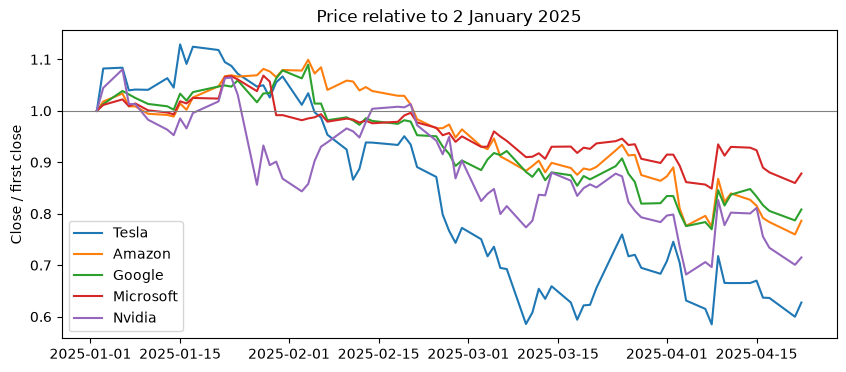

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for t, p in prices.items():
    ax.plot(p.Date, p.Close / p.Close.iloc[0], label=COMPANIES[t])
ax.axhline(1, color="gray", lw=0.8)
ax.set_title("Price relative to 2 January 2025")
ax.set_ylabel("Close / first close")
ax.legend()
plt.show()

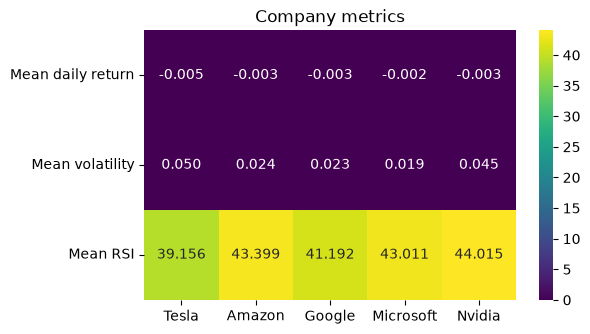

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(summary[["Mean daily return", "Mean volatility", "Mean RSI"]].T,
            annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("Company metrics")
plt.show()

           count   mean    std    min  25%    50%    75%    max
company                                                        
Amazon     145.0  0.208  0.294 -0.718  0.0  0.178  0.402  0.840
Google     143.0  0.108  0.291 -0.791  0.0  0.000  0.318  0.649
Microsoft  185.0  0.127  0.249 -0.527  0.0  0.000  0.318  0.807
Nvidia     169.0  0.067  0.316 -0.718  0.0  0.000  0.272  0.718
Tesla      137.0  0.106  0.317 -0.718  0.0  0.000  0.340  0.818


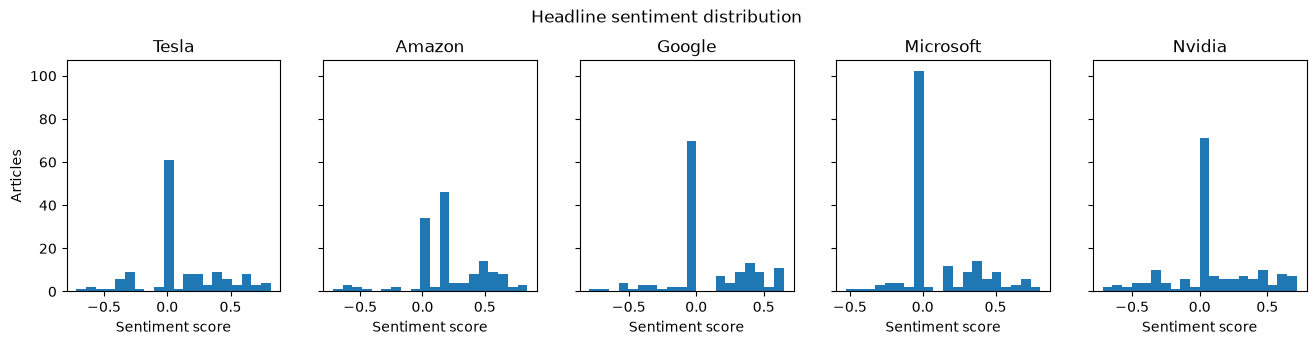

In [8]:
all_news = pd.concat([n.assign(Ticker=t) for t, n in news.items()], ignore_index=True)
print(all_news.groupby("company").sentiment_score.describe().round(3))

fig, axes = plt.subplots(1, 5, figsize=(16, 3), sharey=True)
for ax, (t, n) in zip(axes, news.items()):
    ax.hist(n.sentiment_score, bins=20)
    ax.set_title(COMPANIES[t])
    ax.set_xlabel("Sentiment score")
axes[0].set_ylabel("Articles")
plt.suptitle("Headline sentiment distribution", y=1.05)
plt.show()

Most headlines are neutral (score exactly 0) or mildly positive; negative
headlines are rare. All five stocks fell over the period, most sharply around
the early-April tariff announcements.

## 4. Building the event table

Each article is mapped to its **event day**: the first trading session on or
after its publication date (weekend news is priced on Monday). Several
articles about the same company on the same event day are averaged into one
observation, so a busy news day does not count five times.

Returns are also measured **peer-adjusted**: a stock's return minus the mean
return of the five stocks that day. This removes moves that hit the whole
sector (such as the April sell-off), which would otherwise dominate every
test.

In [9]:
returns = pd.concat([p.set_index("Date").Return.rename(t) for t, p in prices.items()], axis=1)
abnormal = returns.sub(returns.mean(axis=1), axis=0)
trading_days = returns.index

WINDOW = 5
rows = []
for t, n in news.items():
    position = trading_days.searchsorted(n.Date)
    n = n.assign(t0=position)[position < len(trading_days)]
    per_day = n.groupby("t0").agg(sentiment=("sentiment_score", "mean"),
                                  articles=("title", "size"))
    r, a = returns[t].to_numpy(), abnormal[t].to_numpy()
    for i, event in per_day.iterrows():
        # Need 5 clean days before (Return is NaN on the first day) and after.
        if i - WINDOW < 1 or i + WINDOW >= len(trading_days):
            continue
        rows.append({
            "ticker": t,
            "event_day": trading_days[i],
            "sentiment": event.sentiment,
            "articles": event.articles,
            "return_next": r[i + 1],
            "abnormal_next": a[i + 1],
            "car_0_5": a[i:i + WINDOW + 1].sum(),
            "abs_return_pre": np.abs(r[i - WINDOW:i]).mean(),
            "abs_return_post": np.abs(r[i + 1:i + WINDOW + 1]).mean(),
        })

events = pd.DataFrame(rows)
events["label"] = np.select([events.sentiment > 0.05, events.sentiment < -0.05],
                            ["positive", "negative"], "neutral")
print(f"{len(events)} company-day events from {len(all_news)} articles")
print(events.label.value_counts().to_dict())
coverage = {t: trading_days.searchsorted(n.Date) for t, n in news.items()}
print("Trading days with at least one article:",
      {t: f"{len(set(c[c < len(trading_days)]))}/{len(trading_days)}" for t, c in coverage.items()})

315 company-day events from 779 articles
{'positive': 167, 'neutral': 105, 'negative': 43}
Trading days with at least one article: {'TSLA': '74/75', 'AMZN': '74/75', 'GOOG': '74/75', 'MSFT': '74/75', 'NVDA': '74/75'}


**Important consequence.** Every company has AI news on 74 of its 75 trading
days. There are no "quiet" days to compare against, so this data cannot answer
"do announcements move prices compared with no announcement?". What it can
answer is whether the *tone* of the news matters: do days with more positive
coverage see better returns than days with negative coverage? The hypotheses
below are framed that way.

## 5. Sentiment and next-day returns

In [10]:
for col in ["return_next", "abnormal_next"]:
    rho, p = stats.spearmanr(events.sentiment, events[col], alternative="greater")
    print(f"Sentiment vs {col:<14} Spearman rho = {rho:+.3f}, one-sided p = {p:.4f}")

ols = sm.OLS(events.abnormal_next, sm.add_constant(events[["sentiment"]])).fit(cov_type="HC3")
print(ols.summary().tables[1])

Sentiment vs return_next    Spearman rho = +0.112, one-sided p = 0.0232
Sentiment vs abnormal_next  Spearman rho = +0.148, one-sided p = 0.0043
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0013      0.001     -0.941      0.347      -0.004       0.001
sentiment      0.0119      0.005      2.610      0.009       0.003       0.021


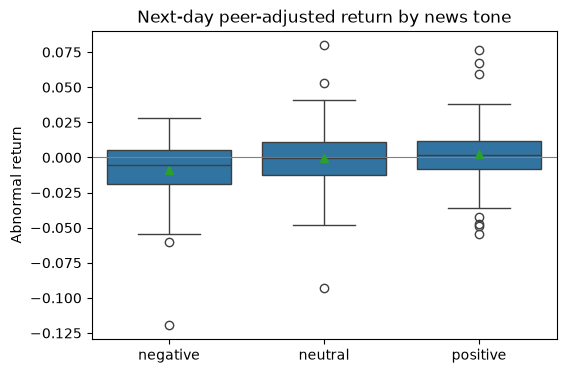

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["negative", "neutral", "positive"]
sns.boxplot(data=events, x="label", y="abnormal_next", order=order, showmeans=True, ax=ax)
ax.axhline(0, color="gray", lw=0.8)
ax.set_title("Next-day peer-adjusted return by news tone")
ax.set_xlabel("")
ax.set_ylabel("Abnormal return")
plt.show()

## 6. Returns around news days

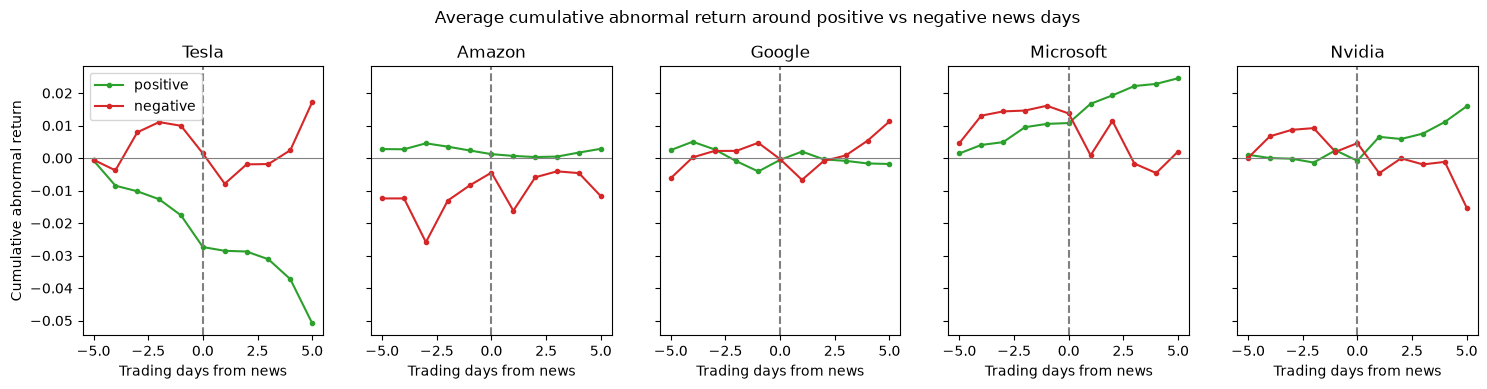

In [12]:
offsets = range(-WINDOW, WINDOW + 1)
paths = []
for _, e in events.iterrows():
    i = trading_days.get_loc(e.event_day)
    path = abnormal[e.ticker].iloc[i - WINDOW:i + WINDOW + 1].cumsum().to_numpy()
    paths.append(pd.DataFrame({"ticker": e.ticker, "label": e.label,
                               "day": list(offsets), "car": path}))
paths = pd.concat(paths)

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)
for ax, t in zip(axes, COMPANIES):
    for label, colour in [("positive", "tab:green"), ("negative", "tab:red")]:
        mean_path = paths[(paths.ticker == t) & (paths.label == label)].groupby("day").car.mean()
        ax.plot(mean_path.index, mean_path.values, marker="o", ms=3, color=colour, label=label)
    ax.axvline(0, ls="--", color="gray")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_title(COMPANIES[t])
    ax.set_xlabel("Trading days from news")
axes[0].set_ylabel("Cumulative abnormal return")
axes[0].legend()
plt.suptitle("Average cumulative abnormal return around positive vs negative news days", y=1.04)
plt.show()

## 7. Hypothesis tests

All tests use alpha = 0.05 and are one-sided where the hypothesis has a
direction. The Holm correction at the end accounts for running several tests
on the same data.

| | Null hypothesis | Alternative |
|---|---|---|
| H1 | Sentiment is unrelated to next-day abnormal return | Higher sentiment, higher return |
| H2 | Positive-news days have the same next-day abnormal return as negative-news days | Positive > negative |
| H3 | Mean absolute return is the same in the 5 days after a news day as in the 5 days before | After > before |
| H4 | The 5-day cumulative abnormal return after news is the same for every company | At least one differs |

In [13]:
results = {}

rho, p = stats.spearmanr(events.sentiment, events.abnormal_next, alternative="greater")
results["H1 sentiment -> next-day abnormal return (Spearman)"] = (rho, p)

pos = events.loc[events.label == "positive", "abnormal_next"]
neg = events.loc[events.label == "negative", "abnormal_next"]
neu = events.loc[events.label == "neutral", "abnormal_next"]
t_stat, p = stats.ttest_ind(pos, neg, equal_var=False, alternative="greater")
results["H2 positive > negative (Welch t)"] = (t_stat, p)
t_stat, p = stats.ttest_ind(pos, neu, equal_var=False, alternative="greater")
results["H2b positive > neutral (Welch t)"] = (t_stat, p)

t_stat, p = stats.ttest_rel(events.abs_return_post, events.abs_return_pre, alternative="greater")
results["H3 volatility after > before (paired t)"] = (t_stat, p)
w_stat, p = stats.wilcoxon(events.abs_return_post, events.abs_return_pre, alternative="greater")
results["H3 volatility after > before (Wilcoxon)"] = (w_stat, p)

groups = [g.car_0_5 for _, g in events.groupby("ticker")]
f_stat, p = stats.f_oneway(*groups)
results["H4 company differences in CAR(0,+5) (ANOVA)"] = (f_stat, p)
h_stat, p = stats.kruskal(*groups)
results["H4 company differences in CAR(0,+5) (Kruskal-Wallis)"] = (h_stat, p)

table = pd.DataFrame(results, index=["statistic", "p"]).T
table["p (Holm)"] = multipletests(table.p, method="holm")[1]
table["reject H0"] = table["p (Holm)"] < 0.05
table.round(4)

,statistic,p,p (Holm),reject H0
H1 sentiment -> next-day abnormal return (Spearman),0.1477,0.0043,0.0216,True
H2 positive > negative (Welch t),2.8374,0.0032,0.0193,True
H2b positive > neutral (Welch t),1.1513,0.1256,0.1419,False
H3 volatility after > before (paired t),1.4724,0.0710,0.1419,False
H3 volatility after > before (Wilcoxon),27946.0000,0.0292,0.0877,False
"H4 company differences in CAR(0,+5) (ANOVA)",3.4228,0.0093,0.0372,True
"H4 company differences in CAR(0,+5) (Kruskal-Wallis)",16.7881,0.0021,0.0149,True


In [14]:
print("Mean next-day abnormal return:",
      {k: f"{v.mean():+.4f}" for k, v in [("positive", pos), ("neutral", neu), ("negative", neg)]})
print(f"Mean absolute return before {events.abs_return_pre.mean():.4f}, "
      f"after {events.abs_return_post.mean():.4f}")
print(events.groupby("ticker").car_0_5.agg(["mean", "std", "count"]).round(4))

Mean next-day abnormal return: {'positive': '+0.0027', 'neutral': '-0.0005', 'negative': '-0.0092'}
Mean absolute return before 0.0238, after 0.0253
          mean     std  count
ticker                       
AMZN    0.0015  0.0305     63
GOOG    0.0031  0.0347     63
MSFT    0.0111  0.0308     63
NVDA    0.0030  0.0632     63
TSLA   -0.0187  0.0654     63


## 8. Results

| | Result | Holm-adjusted p | Decision |
|---|---|---|---|
| H1 | Spearman rho = +0.15 between a day's sentiment and the next day's peer-adjusted return | 0.022 | Reject H0 |
| H2 | Next-day abnormal return +0.27% after positive-news days vs -0.92% after negative-news days | 0.019 | Reject H0 |
| H2b | Positive vs neutral days: +0.27% vs -0.05% | 0.14 | Cannot reject |
| H3 | Mean absolute return 2.38% before vs 2.53% after news days | 0.09 to 0.14 | Cannot reject |
| H4 | 5-day abnormal return after news differs by company (Microsoft +1.1%, Tesla -1.9%) | 0.015 to 0.037 | Reject H0 |

**Interpretation**

- **Tone matters, weakly.** More positive AI coverage is followed by slightly
  better next-day returns relative to the other four stocks, and the gap between
  positive and negative days (about 1.2 percentage points) is significant after
  the multiple-testing correction. Sentiment still explains only a small share
  of the variation: the OLS slope is 0.012 per unit of sentiment.
- **Volatility does not rise after AI news.** The small increase from before to
  after is not significant once corrected for multiple tests, and it mostly
  reflects the market-wide volatility build-up into April.
- **Company matters.** Over this period the market treated the companies
  differently: Microsoft outperformed its peers after news days while Tesla
  fell behind, in line with Tesla's -37% total return.

**Limitations**

- News appears on almost every trading day, so the effect of an announcement
  versus no announcement cannot be measured with this data.
- Only headlines are scored, with a general-purpose lexicon (VADER) that
  misses finance-specific tone.
- Publication times are not available; an article from late in a session is
  treated as known at that day's close.
- Event windows of consecutive days overlap, so the observations are not fully
  independent and the p-values are somewhat optimistic.
- Four months of data from a single falling market.